In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 10,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 10,
                     'lmax': 1500}

use_obs  = ['GC','WL']


In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 
#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}

MG_params={'MG_flag': 0}
fiducial.update(MG_params)
camb_path = '/users/chiaradeleo/Desktop/MGCobaya/MGCAMB' 


In [5]:
distributions = np.load('./mock_data/MG_test_galonly_IApoly_source_distribution.npy',allow_pickle=True).item()


In [6]:
if 'GC' in distributions:
    Nbins_gc=distributions['GC']['Nbins']

if 'WL' in distributions:
    Nbins_wl=distributions['WL']['Nbins']
if Nbins_gc>=Nbins_wl:
    bincolors = sb.color_palette('hls',Nbins_gc)

else:
    bincolors = sb.color_palette('hls',Nbins_wl)

In [7]:
from source_code.compute_obs_sources import get_obs

In [8]:
calc_obs_LCDM = get_obs(fiducial,distributions,ells,camb_path,feedback=True)


CAMB took 5.47 s
Cls packing took 0.04 s
Cls computed in 5.6 s


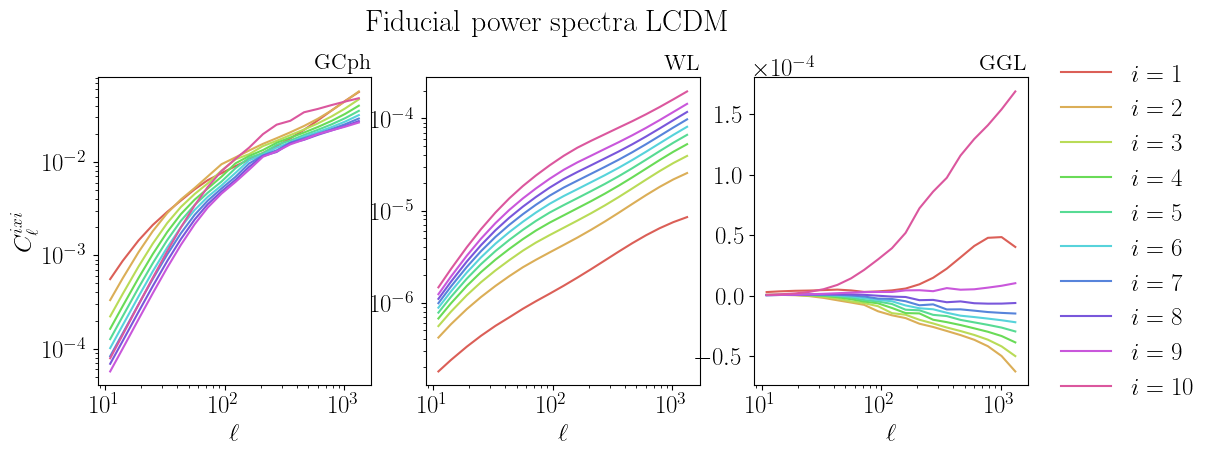

In [9]:
norm = ells*(ells+1)/(2*np.pi)

fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
plt.suptitle('Fiducial power spectra LCDM',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs_LCDM.Cls['G{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')

axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
axes[-1].legend(**sidelegend);

In [10]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}
MG_params={'MG_flag': 1,
           'pure_MG_flag': 2,
           'musigma_par': 1,
           'DE_model': 0,
           'sigma0': -0.17,
           'mu0': 0.0}
fiducial.update(MG_params)

In [11]:
calc_obs_Sigma = get_obs(fiducial,distributions,ells,camb_path,feedback=True)

CAMB took 6.97 s
Cls packing took 0.07 s
Cls computed in 7.1 s


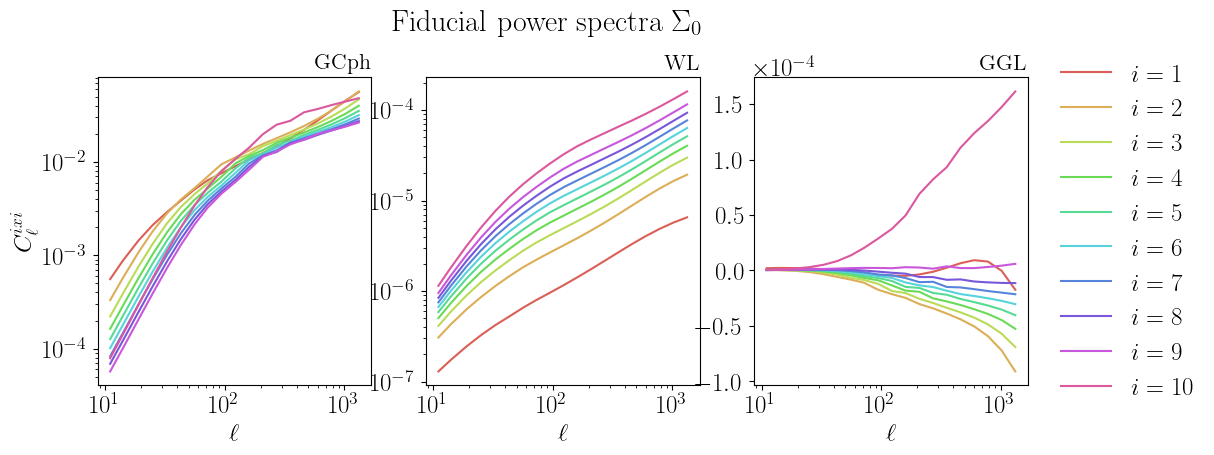

In [12]:
fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
plt.suptitle('Fiducial power spectra $\Sigma_0$',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs_Sigma.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs_Sigma.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        #print(calc_obs_Sigma.Cls['L{}xL{}'.format(i,i)]-calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs_Sigma.Cls['G{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')

axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
axes[-1].legend(**sidelegend);

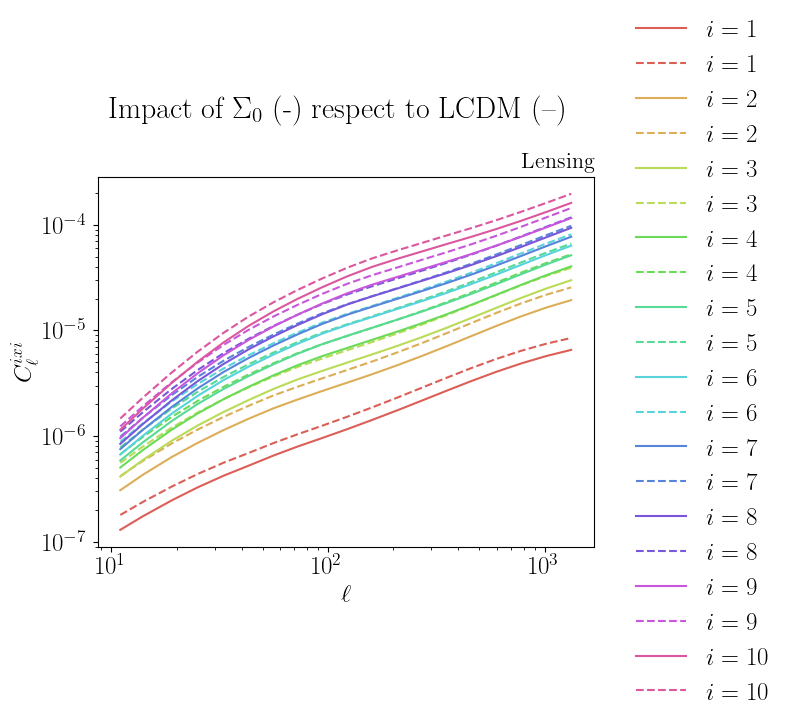

In [13]:

plt.suptitle('Impact of $\Sigma_0$ (-) respect to LCDM (--)',y=1.05)

if 'WL' in use_obs:
    plt.title('Lensing',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
         plt.plot(ells,calc_obs_Sigma.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
         plt.plot(ells,calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--')
    plt.xlabel(r'$\ell$')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.xscale('log')
    plt.yscale('log')


plt.ylabel(r'$C_\ell^{ixi}$')
plt.legend(**sidelegend);

In [14]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}
MG_params={'MG_flag': 1,
           'pure_MG_flag': 2,
           'musigma_par': 1,
           'DE_model': 0,
           'sigma0': 0,
           'mu0': -0.58}
fiducial.update(MG_params)

In [15]:
calc_obs_mu = get_obs(fiducial,distributions,ells,camb_path,feedback=True)

CAMB took 7.10 s
Cls packing took 0.04 s
Cls computed in 7.2 s


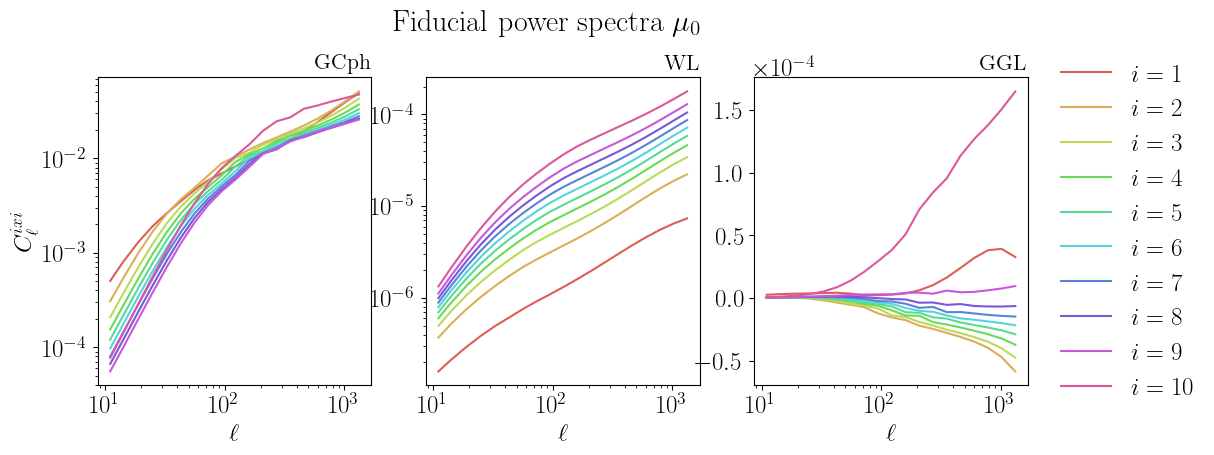

In [16]:
fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
plt.suptitle('Fiducial power spectra $\mu_0$',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs_mu.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs_mu.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs_mu.Cls['G{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')

axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
axes[-1].legend(**sidelegend);

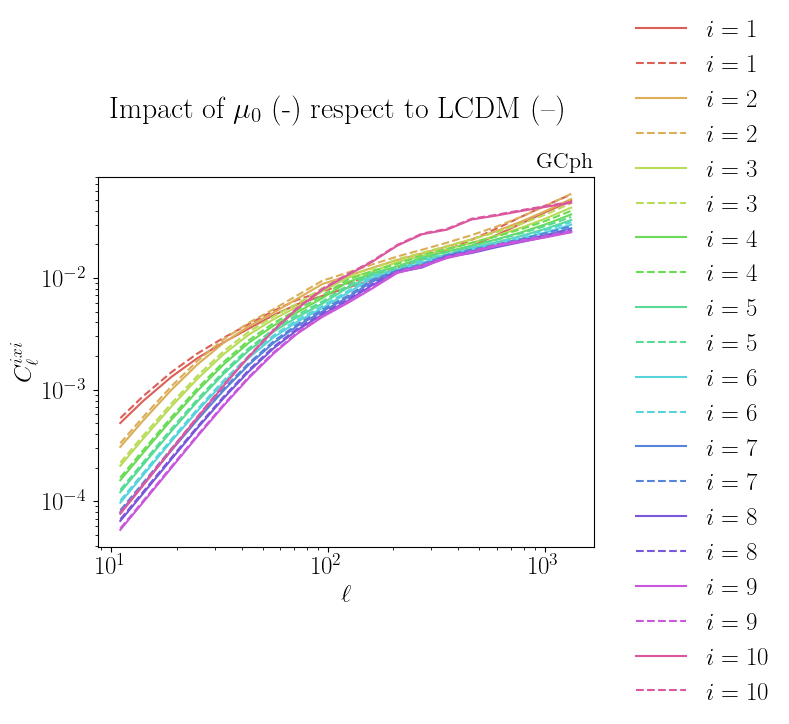

In [23]:

plt.suptitle('Impact of $\mu_0$ (-) respect to LCDM (--)',y=1.05)

if 'GC' in use_obs:
    plt.title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
         plt.plot(ells,calc_obs_mu.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
         plt.plot(ells,calc_obs_Sigma.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--')
         #print((calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]-calc_obs_mu.Cls['G{}xG{}'.format(i,i)])/calc_obs_mu.Cls['G{}xG{}'.format(i,i)])
    plt.xlabel(r'$\ell$')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.xscale('log')
    plt.yscale('log')


plt.ylabel(r'$C_\ell^{ixi}$')
plt.legend(**sidelegend);




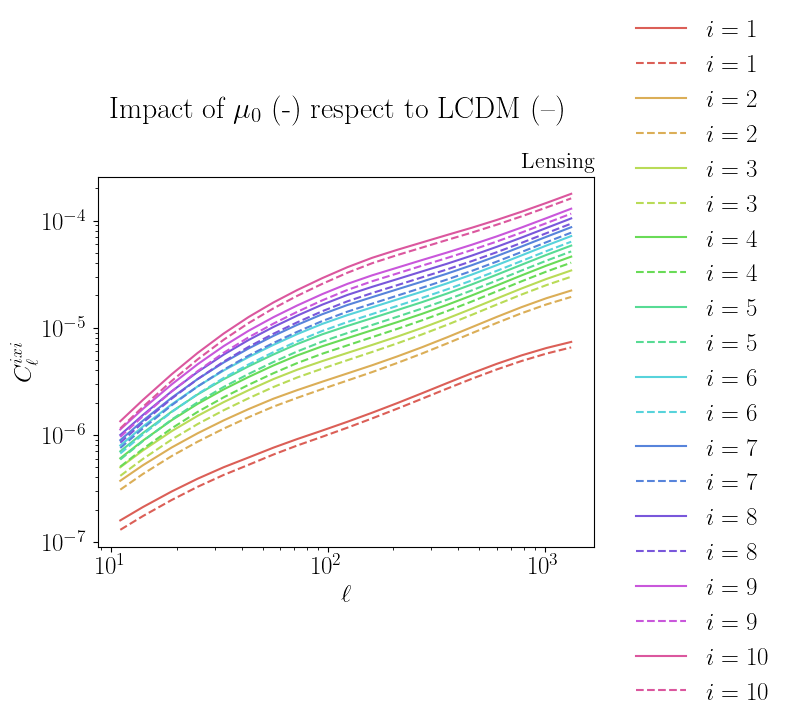

In [18]:
plt.suptitle('Impact of $\mu_0$ (-) respect to LCDM (--)',y=1.05)

if 'GC' in use_obs:
    plt.title('Lensing',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
         plt.plot(ells,calc_obs_mu.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
         plt.plot(ells,calc_obs_Sigma.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1], ls='--')
         #print((calc_obs_mu.Cls['L{}xL{}'.format(i,i)]-calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)])/calc_obs_mu.Cls['L{}xL{}'.format(i,i)])
    plt.xlabel(r'$\ell$')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.xscale('log')
    plt.yscale('log')


plt.ylabel(r'$C_\ell^{ixi}$')
plt.legend(**sidelegend);

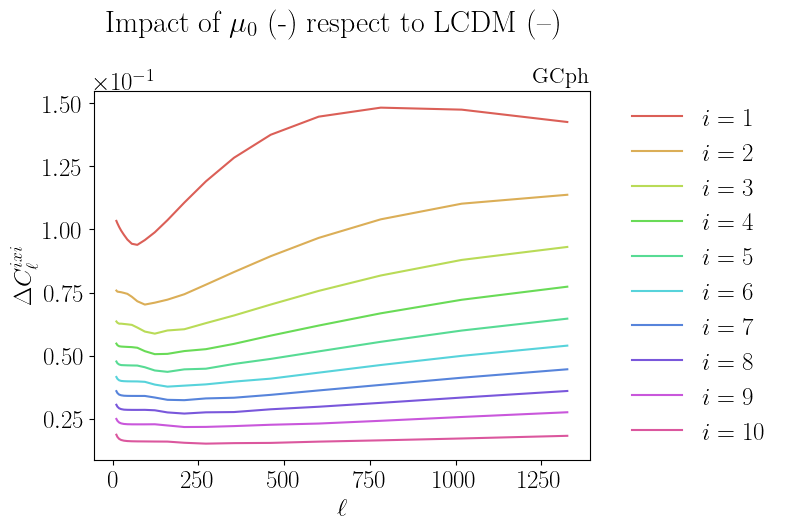

In [26]:
plt.suptitle('Impact of $\mu_0$ (-) respect to LCDM (--)',y=1.05)

if 'GC' in use_obs:
    plt.title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
         plt.plot(ells,(calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)]-calc_obs_mu.Cls['G{}xG{}'.format(i,i)])/calc_obs_mu.Cls['G{}xG{}'.format(i,i)],
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        
    plt.xlabel(r'$\ell$')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))


plt.ylabel(r'$\Delta C_\ell^{ixi}$')
plt.legend(**sidelegend);

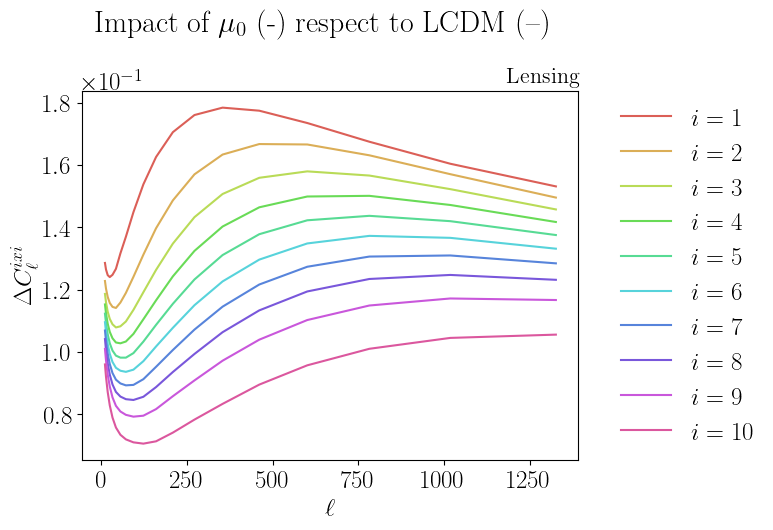

In [25]:
plt.suptitle('Impact of $\mu_0$ (-) respect to LCDM (--)',y=1.05)

if 'GC' in use_obs:
    plt.title('Lensing',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
         plt.plot(ells,(calc_obs_LCDM.Cls['L{}xL{}'.format(i,i)]-calc_obs_mu.Cls['L{}xL{}'.format(i,i)])/calc_obs_mu.Cls['L{}xL{}'.format(i,i)],
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        
    plt.xlabel(r'$\ell$')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))


plt.ylabel(r'$\Delta C_\ell^{ixi}$')
plt.legend(**sidelegend);

In [20]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}
MG_params={'MG_flag': 1,
           'pure_MG_flag': 2,
           'musigma_par': 1,
           'DE_model': 0,
           'sigma0': -0.17,
           'mu0': -0.34}
fiducial.update(MG_params)


In [21]:
calc_obs = get_obs(fiducial,distributions,ells,camb_path,feedback=True)

CAMB took 7.52 s
Cls packing took 0.04 s
Cls computed in 7.6 s


In [22]:
fig, axes = plt.subplots(ncols=3, sharey=False, subplot_kw=dict(frameon=True),figsize=(12,4))
plt.suptitle('Fiducial power spectra $\mu$-$\Sigma$',y=1.05)

if 'GC' in use_obs:
    axes[0].set_title('GCph',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[0].plot(ells,calc_obs.Cls['G{}xG{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
        #print(calc_obs.Cls['G{}xG{}'.format(i,i)]-calc_obs_LCDM.Cls['G{}xG{}'.format(i,i)])
    axes[0].set_xlabel(r'$\ell$')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    
if 'WL' in use_obs:
    axes[1].set_title('WL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_wl+1):
        axes[1].plot(ells,calc_obs.Cls['L{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[1].set_xlabel(r'$\ell$')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    
if 'GC' in use_obs and 'WL' in use_obs:
    axes[2].set_title('GGL',loc='right',fontdict={'fontsize':16})
    for i in range(1,Nbins_gc+1):
        axes[2].plot(ells,calc_obs.Cls['G{}xL{}'.format(i,i)]*norm,
                     label=r'$i={}$'.format(i),color=bincolors[i-1])
    axes[2].set_xlabel(r'$\ell$')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axes[2].set_xscale('log')

axes[0].set_ylabel(r'$C_\ell^{ixi}$')
plt.subplots_adjust(hspace=1.2)
axes[-1].legend(**sidelegend);

Error in callback <function _draw_all_if_interactive at 0x10af9f6a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1200x400 with 3 Axes>